### Series de tiempo
Importamos las librerías necesarias



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

Cargamos el dataset de vuelos y lo visualizamos

In [2]:
# Cargar el dataset 'flights' de Seaborn
flights = sns.load_dataset('flights')
flights

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


Visualizamos el número de pasajeros por aerolínea

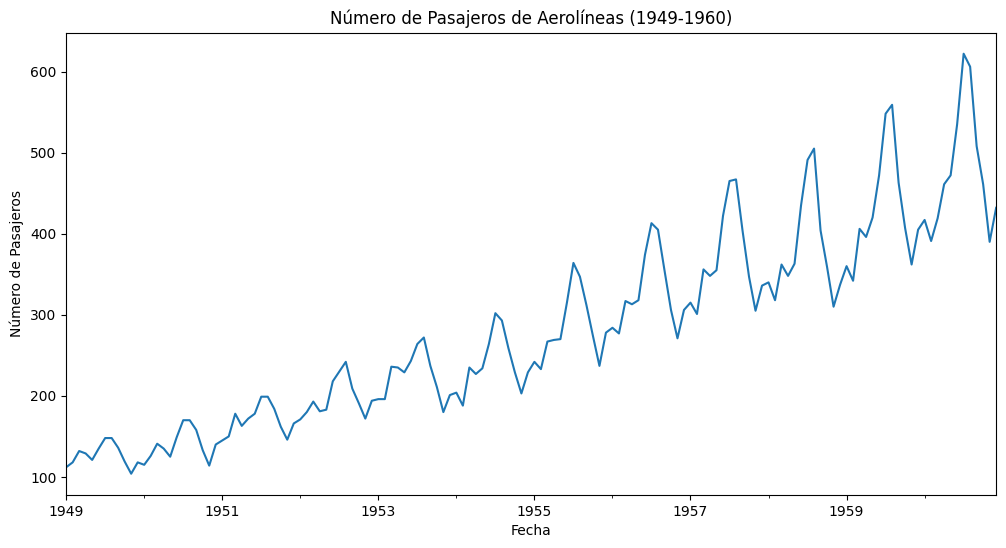

In [3]:


# Convertir la columna 'month' a un formato numérico
month_to_num = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
flights['month'] = flights['month'].map(month_to_num)

# Crear una serie de tiempo con el total de pasajeros por mes
flights['date'] = pd.to_datetime(flights[['year', 'month']].assign(day=1))
flights_series = flights.set_index('date')['passengers']

# Visualización básica de series de tiempo
plt.figure(figsize=(12, 6))
flights_series.plot()
plt.title('Número de Pasajeros de Aerolíneas (1949-1960)')
plt.xlabel('Fecha')
plt.ylabel('Número de Pasajeros')
plt.show()



Descomponemos la serie de tiempo en: Original, Tendndencia, Estacionalidad y Residuos

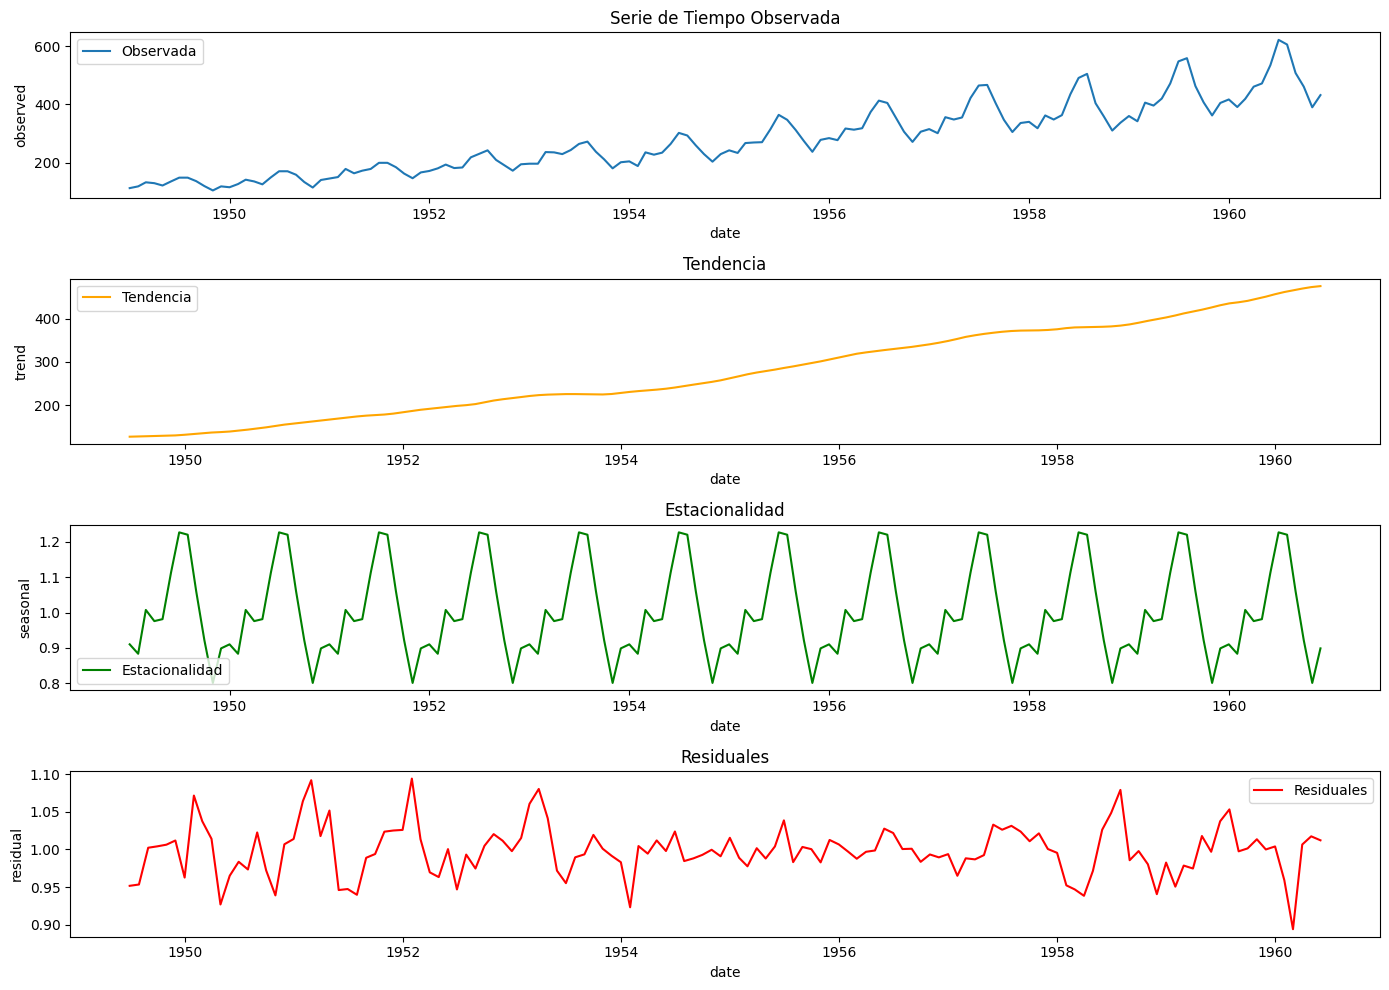

In [4]:


# Descomposición de series de tiempo
result = seasonal_decompose(flights_series, model='multiplicative')

# Preparar los datos para Seaborn
decomp_df = pd.DataFrame({
    'observed': result.observed,
    'trend': result.trend,
    'seasonal': result.seasonal,
    'residual': result.resid
}).reset_index()

# Visualización con Seaborn
plt.figure(figsize=(14, 10))

# Observed
plt.subplot(411)
sns.lineplot(data=decomp_df, x='date', y='observed', label='Observada')
plt.title('Serie de Tiempo Observada')

# Trend
plt.subplot(412)
sns.lineplot(data=decomp_df, x='date', y='trend', label='Tendencia', color='orange')
plt.title('Tendencia')

# Seasonal
plt.subplot(413)
sns.lineplot(data=decomp_df, x='date', y='seasonal', label='Estacionalidad', color='green')
plt.title('Estacionalidad')

# Residual
plt.subplot(414)
sns.lineplot(data=decomp_df, x='date', y='residual', label='Residuales', color='red')
plt.title('Residuales')

plt.tight_layout()
plt.show()
